# 01 — Exploratory Data Analysis: CMTET Dataset

Explore the CMTET code-mixed Telugu-English sentiment dataset.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pathlib import Path

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["font.size"] = 12

DATA_DIR = Path("../data/processed")
RAW_DIR = Path("../data/raw")

## Load the raw CMTET data

The raw file format: `label\ttext` (tab-separated).

In [2]:
df = pd.read_csv(DATA_DIR / "train.csv")
print(f"Train shape: {df.shape}")
print(df.head())

Train shape: (13907, 3)
                                          text_roman     label  text_telugu
0  Tl enti intha prashanthamga untundi anukunttun...  positive          NaN
1           @HarshRo45__ Aa oha chaala bhagundhi bro  positive          NaN
2                Utter floop movie worst chiee 😔 👺 👺  negative          NaN
3  @prashanth_arya5 haa nuvve warning ichav anta ...  positive          NaN
4  RT ivdSAAHO `` RT NTRohit : mana fandome lo ye...  negative          NaN


## Label Distribution

label
positive    5550
negative    5402
neutral     2955
Name: count, dtype: int64


/var/folders/6f/yxwc7q6d31z70tyhr6jyb9nh0000gn/T/ipykernel_28740/757521194.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=label_counts.index, y=label_counts.values, palette="viridis", ax=ax)


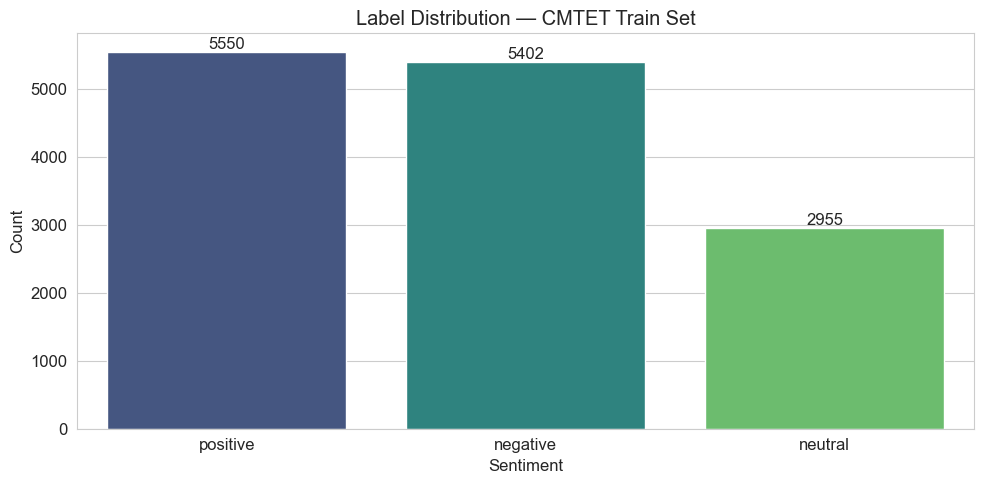

In [3]:
label_counts = df["label"].value_counts()
print(label_counts)

fig, ax = plt.subplots()
sns.barplot(x=label_counts.index, y=label_counts.values, palette="viridis", ax=ax)
ax.set_title("Label Distribution — CMTET Train Set")
ax.set_xlabel("Sentiment")
ax.set_ylabel("Count")
for i, v in enumerate(label_counts.values):
    ax.text(i, v + 50, str(v), ha="center")
plt.tight_layout()
plt.savefig("../report/figures/01_label_distribution.png", dpi=150)
plt.show()

## Sentence Length Distribution

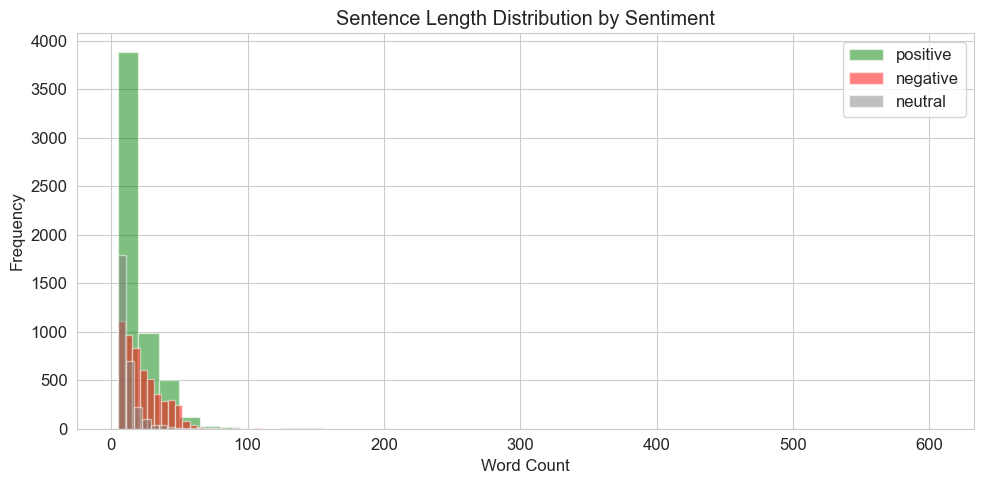

In [4]:
df["text_len"] = df["text_roman"].str.split().str.len()

fig, ax = plt.subplots()
for label, color in zip(["positive", "negative", "neutral"], ["green", "red", "gray"]):
    subset = df[df["label"] == label]["text_len"]
    ax.hist(subset, bins=40, alpha=0.5, label=label, color=color)
ax.set_title("Sentence Length Distribution by Sentiment")
ax.set_xlabel("Word Count")
ax.set_ylabel("Frequency")
ax.legend()
plt.tight_layout()
plt.savefig("../report/figures/02_sentence_length.png", dpi=150)
plt.show()

## Sample Sentences per Class

In [5]:
for label in ["positive", "negative", "neutral"]:
    print(f"\n{'='*60}")
    print(f"  {label.upper()}")
    print(f"{'='*60}")
    samples = df[df["label"] == label]["text_roman"].sample(5, random_state=42)
    for i, s in enumerate(samples, 1):
        print(f"  {i}. {s}")


  POSITIVE
  1. @twinkle_eye Antha idea ledhu anna .. Bane ans ichaav gaa .. 😁 🙌
  2. Mumbai mtch lite tiskotame better 😂 😂 🙏 Aagipoyi manchii pani chesa , mogga gudipestharu kodukulu lekapothe 😂 🙏 Maku namakam ledu doraa bombai mida 🙏 Win ayina kuda maku badha ledu 🙏
  3. Waiting for #Prabhas pics .. Kgf ki ichavv ga 1st day shooting pics Salaar ki kuda ivvu Anna @prashanth_neel #Salaar @prashanth_neel
  4. Thanks Nani Darling Amalapuram Lo Oka Pregnant Lady Ki Emergency Ga AB-Negative Blood Kavali ante ventane midnit Vachi icchav nearly 1.30 Hour Journey Chesi 😘 ❤ ️ 🥰 Lots of Love and Respect Towards you Darling God Bless You ❤ ️ 😍 #DonateBlood 🩸 #SaveLife 🤱
  5. Movie is too good . Good debut all

  NEGATIVE
  1. @bhaaagi_ Cheppanu brother ani chepputho kottina siggu leknda AAth dhi nakuthunnaru gaa 💦 💦 💦
  2. @AroojFatima1017 Chilla aalu lgey ga nahi yaar ! 😒
  3. @ArjunAaryaa_ budget 1rupee pettakapoyina titles lo GMB ni irikistadu mabu gadhuu , kangaru pakalu
  4. @ms_sunshine59